<a href="https://colab.research.google.com/github/zakyboss/170421-3F-AI-Policy-iteration-and-Value-iteration-Assignment/blob/main/updated_value_iteration_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Opening recorded data

In [2]:
value_iteration_data = pd.read_csv("/content/value_iteration.csv")

In [3]:
value_iteration_data.head()

,"(0,0)","(1,0)","(2,0)","(3,0)","(4,0)","(5,0)","(6,0)","(7,0)","(8,0)","(9,0)",...,"(8,17)","(9,17)","(10,17)","(11,17)","(12,17)","(13,17)","(14,17)","(15,17)","(16,17)","(17,17)"
0,0.000000,0,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0,0.000000,0,0,0.000000,0.000000,0.00000,0.000000,0.000000
1,-1.000000,0,0,-0.040000,-1.000000,0,-1.000000,-0.040000,-0.040000,-1.000000,...,-1.000000,0,-1.000000,0,0,-1.000000,-0.040000,-0.04000,-0.040000,1.000000
2,-1.990000,0,0,-0.079600,-1.134640,0,-1.229680,-0.079600,-0.079600,-1.134640,...,-1.229680,0,-1.990000,0,0,-1.134640,-0.079600,-0.07960,0.847040,1.887040
3,-2.970100,0,0,-0.118804,-1.183253,0,-1.306520,-0.118804,-0.118804,-0.530898,...,-1.306520,0,-2.970100,0,0,-1.183253,-0.118804,0.68723,1.633472,2.765210
4,-3.940399,0,0,-0.157616,-1.222996,0,-1.352784,-0.157616,0.315636,-0.051493,...,-0.836119,0,-3.940399,0,0,-0.633676,0.537894,1.38212,2.491838,3.625516


In [4]:
value_iteration_data.tail()

,"(0,0)","(1,0)","(2,0)","(3,0)","(4,0)","(5,0)","(6,0)","(7,0)","(8,0)","(9,0)",...,"(8,17)","(9,17)","(10,17)","(11,17)","(12,17)","(13,17)","(14,17)","(15,17)","(16,17)","(17,17)"
684,-99.896611,0,0,87.408949,85.425257,0,90.706658,93.413273,94.644544,93.828828,...,88.519519,0,-99.896611,0,0,89.559465,91.748183,92.831974,93.488548,94.076444
685,-99.897645,0,0,87.409983,85.426291,0,90.707691,93.414306,94.645577,93.829862,...,88.520537,0,-99.897645,0,0,89.560499,91.749217,92.833008,93.489582,94.077477
686,-99.898669,0,0,87.411007,85.427314,0,90.708715,93.415330,94.646601,93.830885,...,88.521545,0,-99.898669,0,0,89.561522,91.750240,92.834031,93.490605,94.078501
687,-99.899682,0,0,87.412020,85.428327,0,90.709728,93.416343,94.647614,93.831899,...,88.522542,0,-99.899682,0,0,89.562535,91.751254,92.835045,93.491619,94.079514
688,-99.900685,0,0,87.413023,85.429331,0,90.710732,93.417346,94.648617,93.832902,...,88.523529,0,-99.900685,0,0,89.563539,91.752257,92.836048,93.492622,94.080517


### Plotting relevant data

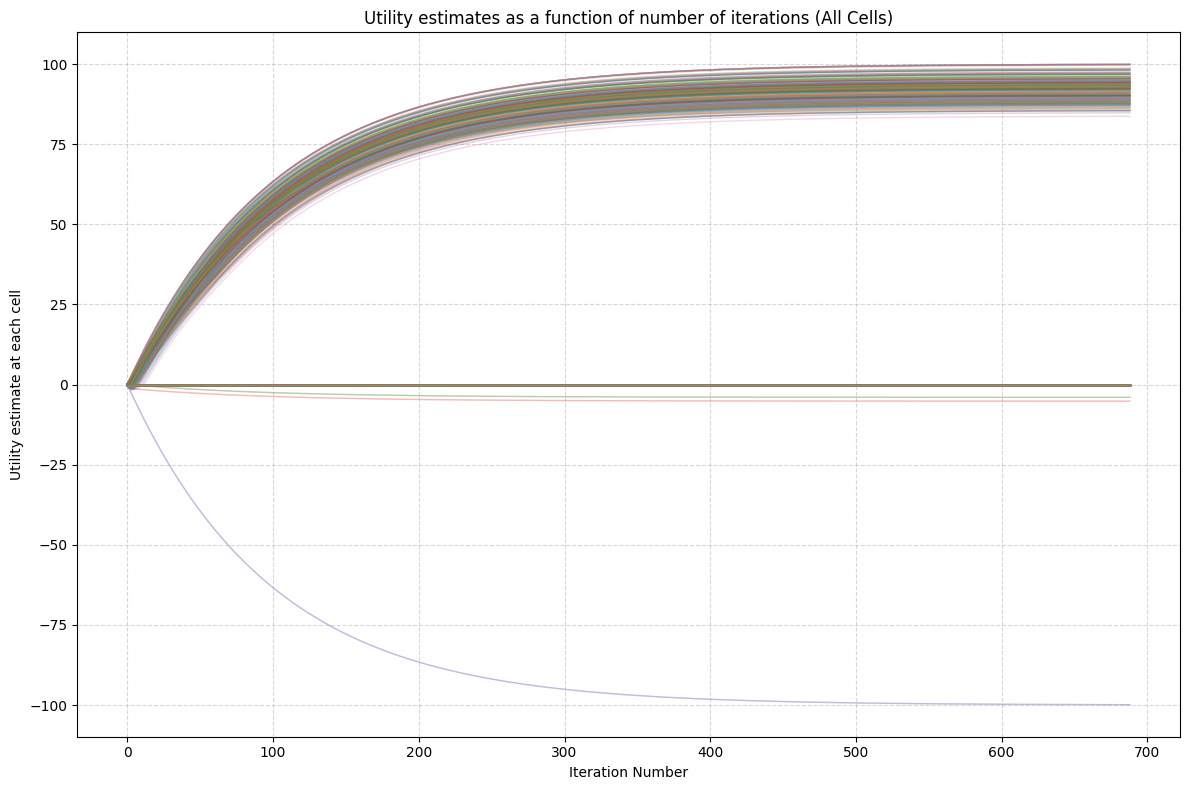

In [5]:
plt.figure(figsize=(12, 8))

# Passing the entire DataFrame plots all columns in a single vectorized step
plt.plot(value_iteration_data, alpha=0.3, linewidth=1)


# Labels & styling
plt.title("Utility estimates as a function of number of iterations (All Cells)")
plt.xlabel("Iteration Number")
plt.ylabel("Utility estimate at each cell")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

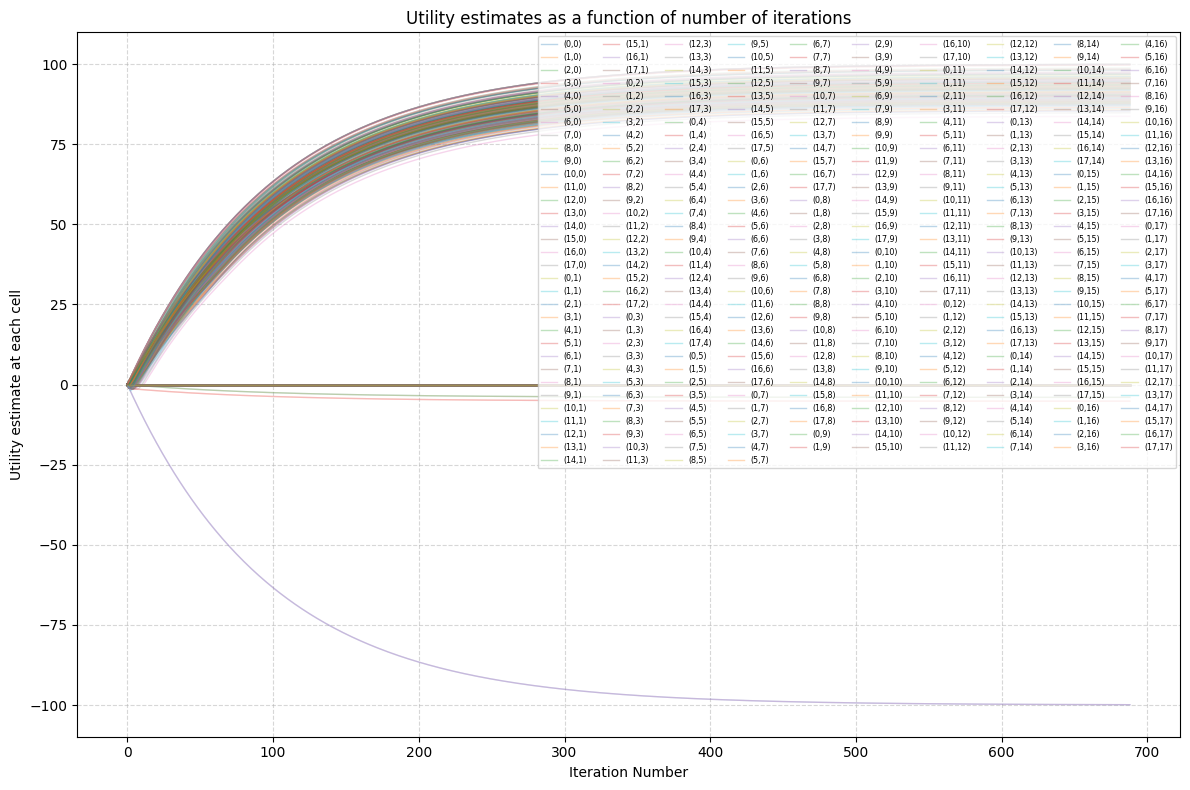

In [6]:
plt.figure(figsize=(12, 8))

for column in value_iteration_data.columns:
  plt.plot(value_iteration_data[column], label=column, alpha=0.3, linewidth=1)

plt.title("Utility estimates as a function of number of iterations")
plt.xlabel("Iteration Number")
plt.ylabel("Utility estimate at each cell")
plt.grid(True, linestyle="--", alpha=0.5)

# Full legend placed at the top right
plt.legend(loc="upper right", fontsize="xx-small", ncol=10)

plt.tight_layout()
plt.show()

---
## Extending the analysis: parameter experiments

The cells above analyze one already-recorded run (`value_iteration.csv`). The cells
below run Value Iteration under several different settings so they can all be
compared together. Before running these cells, upload `environment.py`,
`constants.py`, `complex_constants.py`, and the `algorithms/` folder (containing
`value_iteration.py`) into this Colab session's file browser, matching the same
structure `main.py` expects.


In [7]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"  # constants.py loads a pygame font at import time; this avoids needing a real display
os.environ["SDL_AUDIODRIVER"] = "dummy"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from environment import Environment
from algorithms.value_iteration import ValueIteration


### Grid settings

Same small grid as `constants.py`, plus the bigger random grid from `complex_constants.py`, defined here directly (no need to upload those files separately).

In [8]:
import constants
import complex_constants

# Small grid — from constants.py
small_grid, small_h, small_w = constants.grid, constants.grid_height, constants.grid_width
actions = constants.actions
small_rewards = constants.rewards

# Bigger, randomly generated grid — from complex_constants.py
big_grid, big_h, big_w = complex_constants.grid, complex_constants.grid_height, complex_constants.grid_width
big_rewards = complex_constants.rewards

small_mdp = Environment(small_grid, small_h, small_w, actions, small_rewards)
big_mdp = Environment(big_grid, big_h, big_w, actions, big_rewards)


pygame 2.6.1 (SDL 2.28.4, Python 3.13.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


### All experiments together: discount factor, error threshold, and grid size

Each row below changes **one setting** from the baseline (`γ=0.99`, `error=0.05`, small grid) so the effect of that one change is isolated.

In [9]:
baseline_gamma, baseline_error = 0.99, 0.05

experiments = []

# --- vary discount factor ---
for gamma in [0.1, 0.5, 0.9, 0.99, 0.999]:
    t0 = time.time()
    res = ValueIteration(gamma).solve_mdp(small_mdp, baseline_error)
    experiments.append({"Experiment": "Discount factor", "Setting": f"gamma={gamma}",
                         "Iterations": res["num_iters"], "Time (s)": round(time.time()-t0, 4)})

# --- vary error threshold ---
for scaler in [0.5, 0.1, 0.05, 0.01, 0.001]:
    t0 = time.time()
    res = ValueIteration(baseline_gamma).solve_mdp(small_mdp, scaler)
    experiments.append({"Experiment": "Error threshold", "Setting": f"error={scaler}",
                         "Iterations": res["num_iters"], "Time (s)": round(time.time()-t0, 4)})

# --- vary grid size ---
t0 = time.time()
res_small = ValueIteration(baseline_gamma).solve_mdp(small_mdp, baseline_error)
experiments.append({"Experiment": "Grid size", "Setting": "6x6 (small)",
                     "Iterations": res_small["num_iters"], "Time (s)": round(time.time()-t0, 4)})

t0 = time.time()
res_big = ValueIteration(baseline_gamma).solve_mdp(big_mdp, baseline_error)
experiments.append({"Experiment": "Grid size", "Setting": "18x18 (complex)",
                     "Iterations": res_big["num_iters"], "Time (s)": round(time.time()-t0, 4)})

vi_experiments_df = pd.DataFrame(experiments)
vi_experiments_df


,Experiment,Setting,Iterations,Time (s)
0,Discount factor,gamma=0.1,2,0.0014
1,Discount factor,gamma=0.5,6,0.0031
2,Discount factor,gamma=0.9,51,0.0228
3,Discount factor,gamma=0.99,757,0.3265
4,Discount factor,gamma=0.999,9899,5.7134
5,Error threshold,error=0.5,528,0.2289
6,Error threshold,error=0.1,688,0.2994
7,Error threshold,error=0.05,757,0.3223
8,Error threshold,error=0.01,917,0.4147
9,Error threshold,error=0.001,1146,0.4940


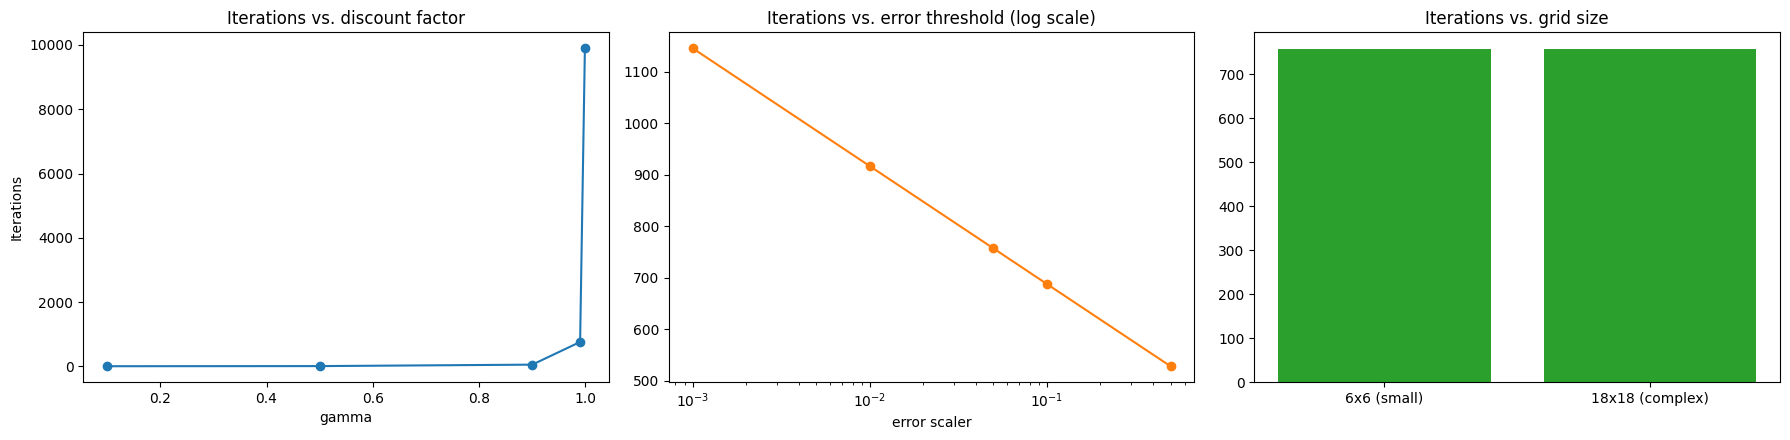

Saved to value_iteration_experiments_summary.csv


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

gamma_rows = vi_experiments_df[vi_experiments_df["Experiment"] == "Discount factor"]
axes[0].plot(gamma_rows["Setting"].str.replace("gamma=", "").astype(float), gamma_rows["Iterations"], marker="o")
axes[0].set_title("Iterations vs. discount factor")
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("Iterations")

error_rows = vi_experiments_df[vi_experiments_df["Experiment"] == "Error threshold"]
axes[1].plot(error_rows["Setting"].str.replace("error=", "").astype(float), error_rows["Iterations"], marker="o", color="tab:orange")
axes[1].set_xscale("log")
axes[1].set_title("Iterations vs. error threshold (log scale)")
axes[1].set_xlabel("error scaler")

grid_rows = vi_experiments_df[vi_experiments_df["Experiment"] == "Grid size"]
axes[2].bar(grid_rows["Setting"], grid_rows["Iterations"], color="tab:green")
axes[2].set_title("Iterations vs. grid size")

plt.tight_layout()
plt.show()

vi_experiments_df.to_csv("value_iteration_experiments_summary.csv", index=False)
print("Saved to value_iteration_experiments_summary.csv")


### Observations

- **Discount factor:** A bigger γ means the agent cares more about rewards far in the future, not just the next step. Caring about the far future means the algorithm has to keep refining its estimates for much longer before they stop changing ,this is why γ=0.999 took thousands more iterations than γ=0.1.
- **Error threshold:** Asking for a more precise final answer (a smaller error value) means the algorithm can't stop as early it has to keep going until the numbers barely change at all. Looser precision means a faster stop; tighter precision means a slower stop.
- **Grid size:** Value Iteration took the exact same number of iterations on the small grid and the big grid. This shows that how long it takes doesn't really depend on the size of the grid it depends mainly on γ and the error threshold.